In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [40]:
df = pd.read_csv("../../data/raw/peshawar_openmeteo_2024_2026.csv")

In [41]:
# Convert timestamp to datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])

print("Shape:", df.shape)

df.head()

Shape: (17544, 20)


,temperature_2m,relative_humidity_2m,pressure_msl,precipitation,wind_speed_10m,wind_direction_10m,timestamp,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,us_aqi,us_aqi_pm2_5,us_aqi_pm10,us_aqi_carbon_monoxide,us_aqi_nitrogen_dioxide,us_aqi_sulphur_dioxide,us_aqi_ozone
0,28.5,86,995.4,0.1,5.1,262,2024-08-01 00:00:00+00:00,38.2,57.6,731.0,33.0,5.3,41.0,107,107,52,7,16,3,24
1,29.7,82,994.7,0.0,7.6,149,2024-08-01 01:00:00+00:00,38.8,62.4,645.0,26.6,4.9,59.0,107,107,53,7,13,3,22
2,29.8,84,995.6,1.1,1.3,56,2024-08-01 02:00:00+00:00,33.3,54.4,525.0,17.7,4.3,85.0,108,108,53,7,9,2,22
3,30.7,79,996.4,1.0,1.1,360,2024-08-01 03:00:00+00:00,23.5,37.8,431.0,10.8,3.7,105.0,107,107,53,7,5,2,24
4,31.5,74,996.8,0.1,5.4,48,2024-08-01 04:00:00+00:00,20.5,32.0,388.0,7.9,3.2,115.0,106,106,53,6,4,2,27


In [42]:
# ============================================================
# DATASET STRUCTURE
# ============================================================

print("=" * 60)
print("DATA TYPES")
print("=" * 60)

print(df.dtypes)

print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)

print(df.isnull().sum())

print("\n" + "=" * 60)
print("DUPLICATE ROWS")
print("=" * 60)

print("Duplicate rows:", df.duplicated().sum())

print("\n" + "=" * 60)
print("DUPLICATE TIMESTAMPS")
print("=" * 60)

print("Duplicate timestamps:", df["timestamp"].duplicated().sum())

DATA TYPES
temperature_2m                         float64
relative_humidity_2m                     int64
pressure_msl                           float64
precipitation                          float64
wind_speed_10m                         float64
wind_direction_10m                       int64
timestamp                  datetime64[ns, UTC]
pm2_5                                  float64
pm10                                   float64
carbon_monoxide                        float64
nitrogen_dioxide                       float64
sulphur_dioxide                        float64
ozone                                  float64
us_aqi                                   int64
us_aqi_pm2_5                             int64
us_aqi_pm10                              int64
us_aqi_carbon_monoxide                   int64
us_aqi_nitrogen_dioxide                  int64
us_aqi_sulphur_dioxide                   int64
us_aqi_ozone                             int64
dtype: object

MISSING VALUES
temperature_2m     

In [43]:
# ============================================================
# DESCRIPTIVE STATISTICS
# ============================================================

pd.set_option("display.max_columns", None)

print("=" * 70)
print("DESCRIPTIVE STATISTICS")
print("=" * 70)

df.describe().T

DESCRIPTIVE STATISTICS


,count,mean,std,min,25%,50%,75%,max
temperature_2m,17544.0,22.905808,9.234715,0.9,15.70,24.30,29.9,46.4
relative_humidity_2m,17544.0,59.266473,22.740041,4.0,41.00,61.00,78.0,100.0
pressure_msl,17544.0,1009.223615,7.871834,988.8,1002.80,1009.50,1015.9,1030.4
precipitation,17544.0,0.079799,0.527838,0.0,0.00,0.00,0.0,13.9
wind_speed_10m,17544.0,4.272076,3.127439,0.0,2.00,3.50,5.7,33.1
wind_direction_10m,17544.0,186.786651,120.887846,1.0,63.00,201.00,304.0,360.0
pm2_5,17544.0,38.388914,22.529980,1.9,21.80,33.90,49.5,156.5
pm10,17544.0,48.775376,27.512109,2.0,28.90,44.05,62.2,499.2
carbon_monoxide,17544.0,1044.238999,774.175390,66.0,455.00,789.00,1419.0,5053.0
nitrogen_dioxide,17544.0,29.447122,24.487174,0.0,9.10,23.70,43.6,127.2


In [44]:
# ============================================================
# AQI STATISTICS
# ============================================================

print("=" * 70)
print("US AQI STATISTICS")
print("=" * 70)

print("Mean AQI:", df["us_aqi"].mean())
print("Median AQI:", df["us_aqi"].median())
print("Minimum AQI:", df["us_aqi"].min())
print("Maximum AQI:", df["us_aqi"].max())
print("Standard deviation:", df["us_aqi"].std())

US AQI STATISTICS
Mean AQI: 112.23312813497492
Median AQI: 107.0
Minimum AQI: 48
Maximum AQI: 212
Standard deviation: 29.716353222740626


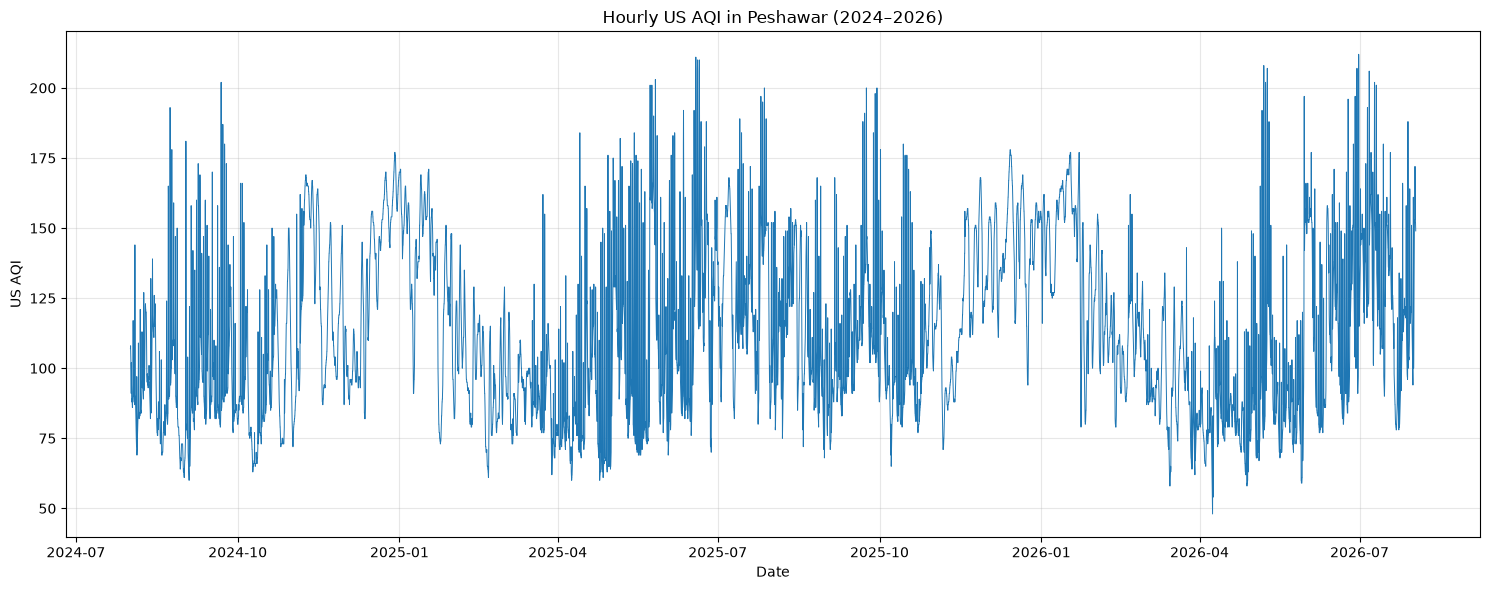

In [45]:
# ============================================================
# AQI OVER TIME
# ============================================================

plt.figure(figsize=(15, 6))

plt.plot(
    df["timestamp"],
    df["us_aqi"],
    linewidth=0.7
)

plt.title("Hourly US AQI in Peshawar (2024–2026)")
plt.xlabel("Date")
plt.ylabel("US AQI")

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

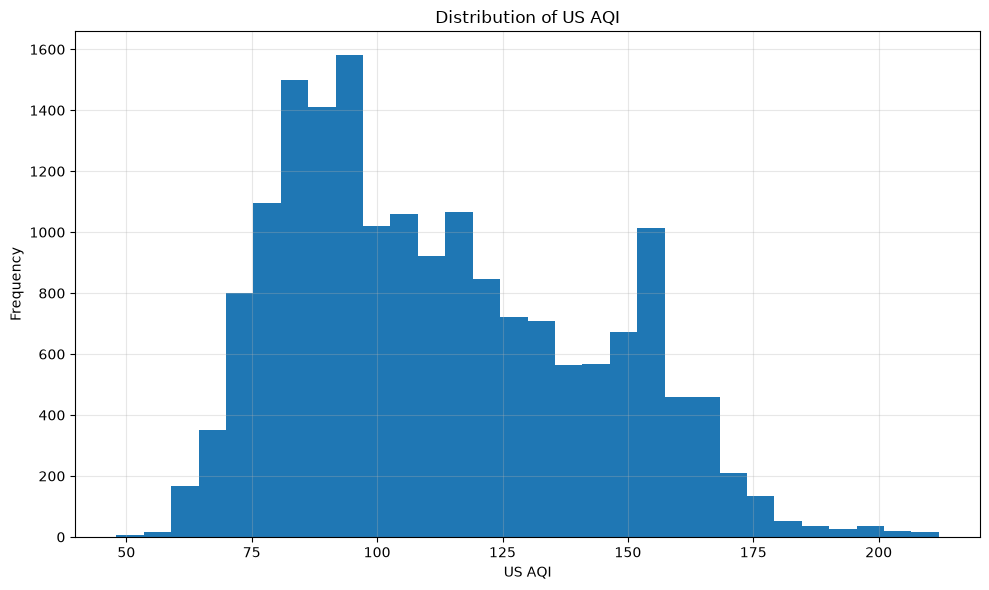

In [46]:
# ============================================================
# AQI DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

plt.hist(
    df["us_aqi"],
    bins=30
)

plt.title("Distribution of US AQI")
plt.xlabel("US AQI")
plt.ylabel("Frequency")

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [47]:
# ============================================================
# AQI CATEGORY DISTRIBUTION
# US EPA AQI CATEGORIES
# ============================================================

def aqi_category(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Moderate"
    elif aqi <= 150:
        return "Unhealthy for Sensitive Groups"
    elif aqi <= 200:
        return "Unhealthy"
    elif aqi <= 300:
        return "Very Unhealthy"
    else:
        return "Hazardous"


df["aqi_category"] = df["us_aqi"].apply(aqi_category)

category_counts = df["aqi_category"].value_counts()

category_percentages = (
    df["aqi_category"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

aqi_categories = pd.DataFrame({
    "Count": category_counts,
    "Percentage": category_percentages
})

print(aqi_categories)

                                Count  Percentage
aqi_category                                     
Moderate                         7582       43.22
Unhealthy for Sensitive Groups   7283       41.51
Unhealthy                        2633       15.01
Very Unhealthy                     44        0.25
Good                                2        0.01


In [48]:
# ============================================================
# DAILY AQI AGGREGATION
# ============================================================

# Create a date column
df["date"] = df["timestamp"].dt.date

# Count hourly observations per day
daily_hour_counts = df.groupby("date").size()

print("=" * 60)
print("DAILY OBSERVATION COUNTS")
print("=" * 60)

print(daily_hour_counts.describe())

print("\nNumber of days:", len(daily_hour_counts))

print("\nDays with fewer than 24 observations:")
print((daily_hour_counts < 24).sum())

print("\nDays with exactly 24 observations:")
print((daily_hour_counts == 24).sum())

DAILY OBSERVATION COUNTS
count    731.0
mean      24.0
std        0.0
min       24.0
25%       24.0
50%       24.0
75%       24.0
max       24.0
dtype: float64

Number of days: 731

Days with fewer than 24 observations:
0

Days with exactly 24 observations:
731


In [49]:
# ============================================================
# CREATE DAILY DATASET
# ============================================================

# Aggregate hourly data into daily values
daily_df = (
    df.groupby("date")
      .agg(
          daily_aqi=("us_aqi", "mean"),
          temperature_mean=("temperature_2m", "mean"),
          temperature_max=("temperature_2m", "max"),
          temperature_min=("temperature_2m", "min"),
          humidity_mean=("relative_humidity_2m", "mean"),
          pressure_mean=("pressure_msl", "mean"),
          precipitation_total=("precipitation", "sum"),
          wind_speed_mean=("wind_speed_10m", "mean"),
          pm2_5_mean=("pm2_5", "mean"),
          pm10_mean=("pm10", "mean"),
          carbon_monoxide_mean=("carbon_monoxide", "mean"),
          nitrogen_dioxide_mean=("nitrogen_dioxide", "mean"),
          sulphur_dioxide_mean=("sulphur_dioxide", "mean"),
          ozone_mean=("ozone", "mean")
      )
      .reset_index()
)

print("=" * 70)
print("DAILY DATASET")
print("=" * 70)

print("Shape:", daily_df.shape)

print("\nFirst 5 days:")
display(daily_df.head())

print("\nLast 5 days:")
display(daily_df.tail())

DAILY DATASET
Shape: (731, 15)

First 5 days:


,date,daily_aqi,temperature_mean,temperature_max,temperature_min,humidity_mean,pressure_mean,precipitation_total,wind_speed_mean,pm2_5_mean,pm10_mean,carbon_monoxide_mean,nitrogen_dioxide_mean,sulphur_dioxide_mean,ozone_mean
0,2024-08-01,97.250000,29.608333,34.0,26.5,77.750000,997.983333,5.2,7.866667,28.962500,43.404167,438.000000,13.625000,5.470833,100.416667
1,2024-08-02,93.416667,30.275000,34.1,25.5,76.333333,997.500000,18.6,4.191667,29.304167,42.425000,503.208333,23.983333,4.829167,83.041667
2,2024-08-03,99.166667,28.883333,33.8,25.1,82.250000,1000.058333,31.0,6.133333,28.004167,40.720833,389.458333,13.320833,4.879167,109.166667
3,2024-08-04,78.666667,27.683333,31.9,25.3,84.916667,1002.216667,12.5,4.912500,22.787500,32.945833,467.791667,21.108333,5.670833,93.958333
4,2024-08-05,86.125000,29.729167,33.6,25.6,81.250000,1000.450000,2.8,4.037500,26.012500,38.225000,476.958333,21.012500,5.375000,86.666667



Last 5 days:


,date,daily_aqi,temperature_mean,temperature_max,temperature_min,humidity_mean,pressure_mean,precipitation_total,wind_speed_mean,pm2_5_mean,pm10_mean,carbon_monoxide_mean,nitrogen_dioxide_mean,sulphur_dioxide_mean,ozone_mean
726,2026-07-28,120.416667,31.400000,36.2,24.7,72.458333,996.120833,1.6,5.416667,37.212500,39.545833,877.666667,31.216667,7.704167,105.166667
727,2026-07-29,121.416667,30.041667,34.4,25.5,76.583333,998.679167,2.4,5.766667,42.562500,49.150000,730.833333,20.712500,7.491667,107.666667
728,2026-07-30,123.458333,30.275000,35.5,25.2,76.916667,998.104167,13.1,6.191667,38.650000,48.841667,563.541667,17.412500,7.433333,113.125000
729,2026-07-31,115.541667,27.583333,30.7,24.6,85.458333,1001.833333,26.5,3.875000,47.604167,50.450000,848.666667,29.733333,6.770833,106.000000
730,2026-08-01,152.333333,29.904167,33.5,25.9,77.875000,1000.237500,0.8,3.958333,54.112500,56.287500,1249.500000,32.658333,8.550000,101.583333


In [50]:
# ============================================================
# VALIDATE DAILY DATASET
# ============================================================

print("=" * 70)
print("DAILY DATASET VALIDATION")
print("=" * 70)

print("Shape:", daily_df.shape)

print("\nMissing values:")
print(daily_df.isnull().sum())

print("\nDuplicate dates:")
print(daily_df["date"].duplicated().sum())

print("\nDate range:")
print("Start:", daily_df["date"].min())
print("End:", daily_df["date"].max())

print("\nDaily AQI statistics:")
print(daily_df["daily_aqi"].describe())

DAILY DATASET VALIDATION
Shape: (731, 15)

Missing values:
date                     0
daily_aqi                0
temperature_mean         0
temperature_max          0
temperature_min          0
humidity_mean            0
pressure_mean            0
precipitation_total      0
wind_speed_mean          0
pm2_5_mean               0
pm10_mean                0
carbon_monoxide_mean     0
nitrogen_dioxide_mean    0
sulphur_dioxide_mean     0
ozone_mean               0
dtype: int64

Duplicate dates:
0

Date range:
Start: 2024-08-01
End: 2026-08-01

Daily AQI statistics:
count    731.000000
mean     112.233128
std       25.688185
min       62.458333
25%       92.229167
50%      107.708333
75%      130.270833
max      176.375000
Name: daily_aqi, dtype: float64


In [51]:
# ============================================================
# FEATURE ENGINEERING - TIME FEATURES
# ============================================================

# Make sure data is sorted chronologically
df = df.sort_values("timestamp").reset_index(drop=True)

# Extract time-based features
df["hour"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.dayofweek
df["day_of_month"] = df["timestamp"].dt.day
df["month"] = df["timestamp"].dt.month

# Weekend indicator
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

print("Time features created successfully!")

print(
    df[
        [
            "timestamp",
            "hour",
            "day_of_week",
            "day_of_month",
            "month",
            "is_weekend"
        ]
    ].head(10)
)

Time features created successfully!
                  timestamp  hour  day_of_week  day_of_month  month  \
0 2024-08-01 00:00:00+00:00     0            3             1      8   
1 2024-08-01 01:00:00+00:00     1            3             1      8   
2 2024-08-01 02:00:00+00:00     2            3             1      8   
3 2024-08-01 03:00:00+00:00     3            3             1      8   
4 2024-08-01 04:00:00+00:00     4            3             1      8   
5 2024-08-01 05:00:00+00:00     5            3             1      8   
6 2024-08-01 06:00:00+00:00     6            3             1      8   
7 2024-08-01 07:00:00+00:00     7            3             1      8   
8 2024-08-01 08:00:00+00:00     8            3             1      8   
9 2024-08-01 09:00:00+00:00     9            3             1      8   

   is_weekend  
0           0  
1           0  
2           0  
3           0  
4           0  
5           0  
6           0  
7           0  
8           0  
9           0  


In [52]:
# ============================================================
# CREATE NEXT-HOUR AQI TARGET
# ============================================================

df["target_aqi"] = df["us_aqi"].shift(-1)

print("Target created successfully!")

print(
    df[
        [
            "timestamp",
            "us_aqi",
            "target_aqi"
        ]
    ].head(10)
)

Target created successfully!
                  timestamp  us_aqi  target_aqi
0 2024-08-01 00:00:00+00:00     107       107.0
1 2024-08-01 01:00:00+00:00     107       108.0
2 2024-08-01 02:00:00+00:00     108       107.0
3 2024-08-01 03:00:00+00:00     107       106.0
4 2024-08-01 04:00:00+00:00     106       105.0
5 2024-08-01 05:00:00+00:00     105       103.0
6 2024-08-01 06:00:00+00:00     103       101.0
7 2024-08-01 07:00:00+00:00     101        98.0
8 2024-08-01 08:00:00+00:00      98        96.0
9 2024-08-01 09:00:00+00:00      96        94.0


In [53]:
# ============================================================
# AQI LAG FEATURES
# ============================================================

lag_hours = [1, 3, 6, 12, 24, 48, 72]

for lag in lag_hours:
    df[f"aqi_lag_{lag}"] = df["us_aqi"].shift(lag)

print("=" * 60)
print("AQI LAG FEATURES CREATED")
print("=" * 60)

print(
    df[
        [
            "timestamp",
            "us_aqi",
            "aqi_lag_1",
            "aqi_lag_3",
            "aqi_lag_6",
            "aqi_lag_12",
            "aqi_lag_24",
            "aqi_lag_48",
            "aqi_lag_72"
        ]
    ].head(80)
)

AQI LAG FEATURES CREATED
                   timestamp  us_aqi  aqi_lag_1  aqi_lag_3  aqi_lag_6  \
0  2024-08-01 00:00:00+00:00     107        NaN        NaN        NaN   
1  2024-08-01 01:00:00+00:00     107      107.0        NaN        NaN   
2  2024-08-01 02:00:00+00:00     108      107.0        NaN        NaN   
3  2024-08-01 03:00:00+00:00     107      108.0      107.0        NaN   
4  2024-08-01 04:00:00+00:00     106      107.0      107.0        NaN   
..                       ...     ...        ...        ...        ...   
75 2024-08-04 03:00:00+00:00      81       83.0       86.0       89.0   
76 2024-08-04 04:00:00+00:00      80       81.0       84.0       88.0   
77 2024-08-04 05:00:00+00:00      79       80.0       83.0       87.0   
78 2024-08-04 06:00:00+00:00      77       79.0       81.0       86.0   
79 2024-08-04 07:00:00+00:00      76       77.0       80.0       84.0   

    aqi_lag_12  aqi_lag_24  aqi_lag_48  aqi_lag_72  
0          NaN         NaN         NaN       

In [54]:
# ============================================================
# POLLUTANT LAG FEATURES
# ============================================================

pollutants = [
    "pm2_5",
    "pm10",
    "carbon_monoxide",
    "nitrogen_dioxide",
    "sulphur_dioxide",
    "ozone"
]

pollution_lags = [1, 3, 6, 24]

for pollutant in pollutants:
    for lag in pollution_lags:
        df[f"{pollutant}_lag_{lag}"] = df[pollutant].shift(lag)

print("=" * 60)
print("POLLUTION LAG FEATURES CREATED")
print("=" * 60)

# Display selected columns
display(
    df[
        [
            "timestamp",
            "pm2_5",
            "pm2_5_lag_1",
            "pm2_5_lag_3",
            "pm2_5_lag_6",
            "pm2_5_lag_24",
            "pm10",
            "pm10_lag_1",
            "pm10_lag_24"
        ]
    ].head(30)
)

print("\nTotal number of columns:", len(df.columns))

POLLUTION LAG FEATURES CREATED


,timestamp,pm2_5,pm2_5_lag_1,pm2_5_lag_3,pm2_5_lag_6,pm2_5_lag_24,pm10,pm10_lag_1,pm10_lag_24
0,2024-08-01 00:00:00+00:00,38.2,NaN,NaN,NaN,NaN,57.6,NaN,NaN
1,2024-08-01 01:00:00+00:00,38.8,38.2,NaN,NaN,NaN,62.4,57.6,NaN
2,2024-08-01 02:00:00+00:00,33.3,38.8,NaN,NaN,NaN,54.4,62.4,NaN
3,2024-08-01 03:00:00+00:00,23.5,33.3,38.2,NaN,NaN,37.8,54.4,NaN
4,2024-08-01 04:00:00+00:00,20.5,23.5,38.8,NaN,NaN,32.0,37.8,NaN
5,2024-08-01 05:00:00+00:00,14.2,20.5,33.3,NaN,NaN,22.0,32.0,NaN
6,2024-08-01 06:00:00+00:00,10.0,14.2,23.5,38.2,NaN,15.3,22.0,NaN
7,2024-08-01 07:00:00+00:00,10.4,10.0,20.5,38.8,NaN,15.8,15.3,NaN
8,2024-08-01 08:00:00+00:00,9.9,10.4,14.2,33.3,NaN,15.4,15.8,NaN
9,2024-08-01 09:00:00+00:00,10.4,9.9,10.0,23.5,NaN,15.7,15.4,NaN



Total number of columns: 59


In [55]:
# ============================================================
# ROLLING FEATURES
# ============================================================

# AQI rolling means
df["aqi_3h_mean"] = (
    df["us_aqi"]
    .shift(1)
    .rolling(window=3)
    .mean()
)

df["aqi_6h_mean"] = (
    df["us_aqi"]
    .shift(1)
    .rolling(window=6)
    .mean()
)

df["aqi_12h_mean"] = (
    df["us_aqi"]
    .shift(1)
    .rolling(window=12)
    .mean()
)

df["aqi_24h_mean"] = (
    df["us_aqi"]
    .shift(1)
    .rolling(window=24)
    .mean()
)


# PM2.5 rolling means
df["pm2_5_3h_mean"] = (
    df["pm2_5"]
    .shift(1)
    .rolling(window=3)
    .mean()
)

df["pm2_5_6h_mean"] = (
    df["pm2_5"]
    .shift(1)
    .rolling(window=6)
    .mean()
)

df["pm2_5_24h_mean"] = (
    df["pm2_5"]
    .shift(1)
    .rolling(window=24)
    .mean()
)


# PM10 rolling means
df["pm10_3h_mean"] = (
    df["pm10"]
    .shift(1)
    .rolling(window=3)
    .mean()
)

df["pm10_6h_mean"] = (
    df["pm10"]
    .shift(1)
    .rolling(window=6)
    .mean()
)

df["pm10_24h_mean"] = (
    df["pm10"]
    .shift(1)
    .rolling(window=24)
    .mean()
)


# Other pollutant 24-hour rolling means
pollutants = [
    "carbon_monoxide",
    "nitrogen_dioxide",
    "sulphur_dioxide",
    "ozone"
]

for pollutant in pollutants:
    df[f"{pollutant}_24h_mean"] = (
        df[pollutant]
        .shift(1)
        .rolling(window=24)
        .mean()
    )


print("=" * 60)
print("ROLLING FEATURES CREATED")
print("=" * 60)

print("Total columns:", len(df.columns))

display(
    df[
        [
            "timestamp",
            "us_aqi",
            "aqi_3h_mean",
            "aqi_6h_mean",
            "aqi_24h_mean",
            "pm2_5",
            "pm2_5_3h_mean",
            "pm2_5_24h_mean",
            "pm10",
            "pm10_24h_mean"
        ]
    ].iloc[20:30]
)

ROLLING FEATURES CREATED
Total columns: 73


,timestamp,us_aqi,aqi_3h_mean,aqi_6h_mean,aqi_24h_mean,pm2_5,pm2_5_3h_mean,pm2_5_24h_mean,pm10,pm10_24h_mean
20,2024-08-01 20:00:00+00:00,89,88.333333,92.000000,NaN,39.3,41.066667,NaN,56.7,NaN
21,2024-08-01 21:00:00+00:00,89,88.666667,90.166667,NaN,38.1,40.666667,NaN,54.6,NaN
22,2024-08-01 22:00:00+00:00,89,89.000000,88.833333,NaN,36.8,39.466667,NaN,52.4,NaN
23,2024-08-01 23:00:00+00:00,88,89.000000,88.666667,NaN,35.5,38.066667,NaN,50.6,NaN
24,2024-08-02 00:00:00+00:00,88,88.666667,88.666667,97.250000,31.9,36.800000,28.962500,45.1,43.404167
25,2024-08-02 01:00:00+00:00,87,88.333333,88.666667,96.458333,30.6,34.733333,28.700000,43.3,42.883333
26,2024-08-02 02:00:00+00:00,87,87.666667,88.333333,95.625000,31.0,32.666667,28.358333,44.0,42.087500
27,2024-08-02 03:00:00+00:00,86,87.333333,88.000000,94.750000,28.8,31.166667,28.262500,41.7,41.654167
28,2024-08-02 04:00:00+00:00,87,86.666667,87.500000,93.875000,27.2,30.133333,28.483333,39.3,41.816667
29,2024-08-02 05:00:00+00:00,87,86.666667,87.166667,93.083333,28.6,29.000000,28.762500,41.9,42.120833


In [56]:
# ============================================================
# AQI AND POLLUTANT CHANGE FEATURES
# ============================================================

# AQI changes
df["aqi_change_1h"] = (
    df["us_aqi"] - df["aqi_lag_1"]
)

df["aqi_change_3h"] = (
    df["us_aqi"] - df["aqi_lag_3"]
)

df["aqi_change_6h"] = (
    df["us_aqi"] - df["aqi_lag_6"]
)

df["aqi_change_24h"] = (
    df["us_aqi"] - df["aqi_lag_24"]
)


# PM2.5 changes
df["pm2_5_change_1h"] = (
    df["pm2_5"] - df["pm2_5_lag_1"]
)

df["pm2_5_change_24h"] = (
    df["pm2_5"] - df["pm2_5_lag_24"]
)


# PM10 changes
df["pm10_change_1h"] = (
    df["pm10"] - df["pm10_lag_1"]
)

df["pm10_change_24h"] = (
    df["pm10"] - df["pm10_lag_24"]
)


print("=" * 60)
print("CHANGE FEATURES CREATED")
print("=" * 60)

display(
    df[
        [
            "timestamp",
            "us_aqi",
            "aqi_change_1h",
            "aqi_change_3h",
            "aqi_change_6h",
            "aqi_change_24h",
            "pm2_5",
            "pm2_5_change_1h",
            "pm10",
            "pm10_change_1h"
        ]
    ].iloc[24:35]
)

CHANGE FEATURES CREATED


,timestamp,us_aqi,aqi_change_1h,aqi_change_3h,aqi_change_6h,aqi_change_24h,pm2_5,pm2_5_change_1h,pm10,pm10_change_1h
24,2024-08-02 00:00:00+00:00,88,0.0,-1.0,0.0,-19.0,31.9,-3.6,45.1,-5.5
25,2024-08-02 01:00:00+00:00,87,-1.0,-2.0,-2.0,-20.0,30.6,-1.3,43.3,-1.8
26,2024-08-02 02:00:00+00:00,87,0.0,-1.0,-2.0,-21.0,31.0,0.4,44.0,0.7
27,2024-08-02 03:00:00+00:00,86,-1.0,-2.0,-3.0,-21.0,28.8,-2.2,41.7,-2.3
28,2024-08-02 04:00:00+00:00,87,1.0,0.0,-2.0,-19.0,27.2,-1.6,39.3,-2.4
29,2024-08-02 05:00:00+00:00,87,0.0,0.0,-1.0,-18.0,28.6,1.4,41.9,2.6
30,2024-08-02 06:00:00+00:00,88,1.0,2.0,0.0,-15.0,29.0,0.4,43.1,1.2
31,2024-08-02 07:00:00+00:00,90,2.0,3.0,3.0,-11.0,28.2,-0.8,42.0,-1.1
32,2024-08-02 08:00:00+00:00,91,1.0,4.0,4.0,-7.0,28.1,-0.1,42.0,0.0
33,2024-08-02 09:00:00+00:00,93,2.0,5.0,7.0,-3.0,27.2,-0.9,40.7,-1.3


In [57]:
# ============================================================
# REMOVE ROWS CREATED BEFORE ENOUGH HISTORY WAS AVAILABLE
# ============================================================

print("Before removing NaN rows:")
print("Shape:", df.shape)

df_model = df.dropna().copy()

print("\nAfter removing NaN rows:")
print("Shape:", df_model.shape)

print("\nRemaining missing values:")
print(df_model.isnull().sum().sum())

Before removing NaN rows:
Shape: (17544, 81)

After removing NaN rows:
Shape: (17471, 81)

Remaining missing values:
0


In [58]:
# ============================================================
# DEFINE FEATURES (X) AND TARGET (y)
# ============================================================

TARGET = "target_aqi"

# Columns that must NOT be used as model features
excluded_columns = [
    "timestamp",
    "target_aqi",
    "us_aqi",
    "us_aqi_pm2_5",
    "us_aqi_pm10",
    "us_aqi_carbon_monoxide",
    "us_aqi_nitrogen_dioxide",
    "us_aqi_sulphur_dioxide",
    "us_aqi_ozone",
    "aqi_category",
    "date"
]

feature_columns = [
    col for col in df_model.columns
    if col not in excluded_columns
]

X = df_model[feature_columns]
y = df_model[TARGET]

print("=" * 60)
print("MODEL DATASET")
print("=" * 60)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nNumber of features:", len(feature_columns))

print("\nFeatures:")
for i, feature in enumerate(feature_columns, start=1):
    print(f"{i:2}. {feature}")

print("\nTarget:")
print(TARGET)

MODEL DATASET
X shape: (17471, 70)
y shape: (17471,)

Number of features: 70

Features:
 1. temperature_2m
 2. relative_humidity_2m
 3. pressure_msl
 4. precipitation
 5. wind_speed_10m
 6. wind_direction_10m
 7. pm2_5
 8. pm10
 9. carbon_monoxide
10. nitrogen_dioxide
11. sulphur_dioxide
12. ozone
13. hour
14. day_of_week
15. day_of_month
16. month
17. is_weekend
18. aqi_lag_1
19. aqi_lag_3
20. aqi_lag_6
21. aqi_lag_12
22. aqi_lag_24
23. aqi_lag_48
24. aqi_lag_72
25. pm2_5_lag_1
26. pm2_5_lag_3
27. pm2_5_lag_6
28. pm2_5_lag_24
29. pm10_lag_1
30. pm10_lag_3
31. pm10_lag_6
32. pm10_lag_24
33. carbon_monoxide_lag_1
34. carbon_monoxide_lag_3
35. carbon_monoxide_lag_6
36. carbon_monoxide_lag_24
37. nitrogen_dioxide_lag_1
38. nitrogen_dioxide_lag_3
39. nitrogen_dioxide_lag_6
40. nitrogen_dioxide_lag_24
41. sulphur_dioxide_lag_1
42. sulphur_dioxide_lag_3
43. sulphur_dioxide_lag_6
44. sulphur_dioxide_lag_24
45. ozone_lag_1
46. ozone_lag_3
47. ozone_lag_6
48. ozone_lag_24
49. aqi_3h_mean
50. aq

In [59]:
# ============================================================
# VERIFY TARGET
# ============================================================

print("=" * 60)
print("TARGET VERIFICATION")
print("=" * 60)

print("First timestamp:", df_model["timestamp"].min())
print("Last timestamp:", df_model["timestamp"].max())

print("\nFirst 10 target values:")

display(
    df_model[
        ["timestamp", "us_aqi", "target_aqi"]
    ].head(10)
)

print("\nLast 10 target values:")

display(
    df_model[
        ["timestamp", "us_aqi", "target_aqi"]
    ].tail(10)
)

TARGET VERIFICATION
First timestamp: 2024-08-04 00:00:00+00:00
Last timestamp: 2026-08-01 22:00:00+00:00

First 10 target values:


,timestamp,us_aqi,target_aqi
72,2024-08-04 00:00:00+00:00,86,84.0
73,2024-08-04 01:00:00+00:00,84,83.0
74,2024-08-04 02:00:00+00:00,83,81.0
75,2024-08-04 03:00:00+00:00,81,80.0
76,2024-08-04 04:00:00+00:00,80,79.0
77,2024-08-04 05:00:00+00:00,79,77.0
78,2024-08-04 06:00:00+00:00,77,76.0
79,2024-08-04 07:00:00+00:00,76,75.0
80,2024-08-04 08:00:00+00:00,75,74.0
81,2024-08-04 09:00:00+00:00,74,73.0



Last 10 target values:


,timestamp,us_aqi,target_aqi
17533,2026-08-01 13:00:00+00:00,172,165.0
17534,2026-08-01 14:00:00+00:00,165,153.0
17535,2026-08-01 15:00:00+00:00,153,153.0
17536,2026-08-01 16:00:00+00:00,153,153.0
17537,2026-08-01 17:00:00+00:00,153,152.0
17538,2026-08-01 18:00:00+00:00,152,152.0
17539,2026-08-01 19:00:00+00:00,152,152.0
17540,2026-08-01 20:00:00+00:00,152,151.0
17541,2026-08-01 21:00:00+00:00,151,150.0
17542,2026-08-01 22:00:00+00:00,150,149.0


In [60]:
# ============================================================
# CHRONOLOGICAL TRAIN / VALIDATION / TEST SPLIT
# ============================================================


# Make sure data is sorted chronologically
model_df = df_model.sort_values("timestamp").reset_index(drop=True)

X = model_df[feature_columns]
y = model_df["target_aqi"]

n = len(model_df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train = X.iloc[:train_end].copy()
y_train = y.iloc[:train_end].copy()

X_val = X.iloc[train_end:val_end].copy()
y_val = y.iloc[train_end:val_end].copy()

X_test = X.iloc[val_end:].copy()
y_test = y.iloc[val_end:].copy()

print("=" * 60)
print("CHRONOLOGICAL DATA SPLIT")
print("=" * 60)

print("Training:")
print("X:", X_train.shape)
print("y:", y_train.shape)

print("\nValidation:")
print("X:", X_val.shape)
print("y:", y_val.shape)

print("\nTesting:")
print("X:", X_test.shape)
print("y:", y_test.shape)

print("\nDate ranges:")
print(
    "Train:",
    model_df.iloc[0]["timestamp"],
    "→",
    model_df.iloc[train_end - 1]["timestamp"]
)

print(
    "Validation:",
    model_df.iloc[train_end]["timestamp"],
    "→",
    model_df.iloc[val_end - 1]["timestamp"]
)

print(
    "Test:",
    model_df.iloc[val_end]["timestamp"],
    "→",
    model_df.iloc[-1]["timestamp"]
)

CHRONOLOGICAL DATA SPLIT
Training:
X: (12229, 70)
y: (12229,)

Validation:
X: (2621, 70)
y: (2621,)

Testing:
X: (2621, 70)
y: (2621,)

Date ranges:
Train: 2024-08-04 00:00:00+00:00 → 2025-12-26 12:00:00+00:00
Validation: 2025-12-26 13:00:00+00:00 → 2026-04-14 17:00:00+00:00
Test: 2026-04-14 18:00:00+00:00 → 2026-08-01 22:00:00+00:00


In [61]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

X_test_scaled = scaler.transform(X_test)

print("Scaling completed.")

print("X_train:", X_train_scaled.shape)
print("X_val:", X_val_scaled.shape)
print("X_test:", X_test_scaled.shape)

Scaling completed.
X_train: (12229, 70)
X_val: (2621, 70)
X_test: (2621, 70)


In [62]:
from pathlib import Path

PROJECT_ROOT = Path(r"D:\Internship\pearls-aqi-predictor")

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

aqi_features_path = PROCESSED_DIR / "aqi_features.csv"

model_df.to_csv(aqi_features_path, index=False)

print("=" * 60)
print("FEATURE DATASET SAVED")
print("=" * 60)
print("Path:", aqi_features_path)
print("Shape:", model_df.shape)

FEATURE DATASET SAVED
Path: D:\Internship\pearls-aqi-predictor\data\processed\aqi_features.csv
Shape: (17471, 81)


In [63]:
check = pd.read_csv(aqi_features_path)

print("Shape:", check.shape)
print("Missing values:", check.isna().sum().sum())
print("Duplicate rows:", check.duplicated().sum())

Shape: (17471, 81)
Missing values: 0
Duplicate rows: 0


In [69]:
df = pd.read_csv(aqi_features_path)

# One-location dataset
df["location_id"] = "peshawar"

# Save updated feature dataset
df.to_csv(aqi_features_path, index=False)

print("Saved successfully.")
print("Shape:", df.shape)
print("\nlocation_id values:")
print(df["location_id"].unique())

Saved successfully.
Shape: (17471, 82)

location_id values:
['peshawar']


In [71]:
parquet_path = PROCESSED_DIR/"aqi_features.parquet"

df = pd.read_csv(aqi_features_path)

df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)

df.to_parquet(parquet_path, index=False)

print("Parquet created successfully")
print("Shape:", df.shape)
print("Path:", parquet_path)

Parquet created successfully
Shape: (17471, 82)
Path: D:\Internship\pearls-aqi-predictor\data\processed\aqi_features.parquet
